In [1]:
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Input, Dropout
from keras.layers import Dense
from keras.layers import RepeatVector
from keras.layers import TimeDistributed
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from keras.models import Model
import seaborn as sns
import scipy

In [2]:
data = pd.read_csv('./data/GE.csv')
data = data.drop('Open', axis = 1)

In [3]:
data.head()

,Date,High,Low,Close,Adj Close,Volume
0,1970-01-23,5.959535,5.839343,5.849359,1.207645,476736
1,1970-01-26,5.859375,5.829327,5.849359,1.207645,283296
2,1970-01-27,5.959535,5.849359,5.939503,1.226255,247104
3,1970-01-28,6.009615,5.939503,5.939503,1.226255,545376
4,1970-01-29,5.989583,5.879407,5.879407,1.213848,466752


([<matplotlib.axis.XTick at 0x1b11e9b7af0>,
 [Text(0, 0, '1970-01-23'),
  Text(1600, 0, '1976-05-24'),
  Text(3200, 0, '1982-09-23'),
  Text(4800, 0, '1989-01-20'),
  Text(6400, 0, '1995-05-19'),
  Text(8000, 0, '2001-09-26'),
  Text(9600, 0, '2008-02-05'),
  Text(11200, 0, '2014-06-13'),
  Text(12800, 0, '2020-10-20')])

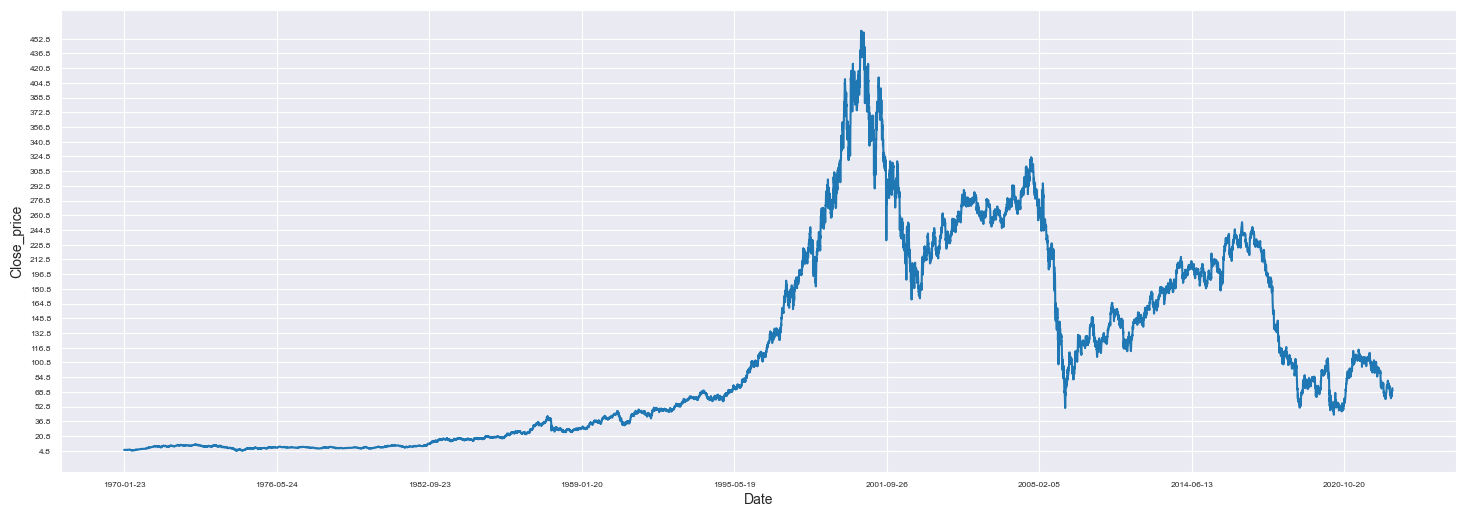

In [102]:
plt.figure(figsize= (18,6))
plt.plot(data['Date'], data['Close'])
plt.xlabel('Date')
plt.ylabel('Close_price')
plt.yticks(np.arange(data['Close'].min(), data['Close'].max(), 16),size = 6)
plt.xticks([ i for i in range(0,data.count()[0],1600) ], size = 6)

In [5]:
train, test = data.iloc[:int(len(data)*0.6),:], data.iloc[int(len(data)*0.6):,:]

In [6]:
scaler = MinMaxScaler()
scaler = scaler.fit(train[['Close']])

In [7]:
train['Close'] = scaler.transform(train[['Close']])
test['Close'] = scaler.transform(test[['Close']])

C:\Users\1\AppData\Local\Temp\ipykernel_13664\2411660821.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Close'] = scaler.transform(train[['Close']])
C:\Users\1\AppData\Local\Temp\ipykernel_13664\2411660821.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Close'] = scaler.transform(test[['Close']])


In [28]:
seq_size = 45

In [29]:
def to_sequences(x, y, seq_size=1):
    x_values = []
    y_values = []

    for i in range(len(x)-seq_size):
        #print(i)
        x_values.append(x.iloc[i:(i+seq_size)].values)
        y_values.append(y.iloc[i+seq_size])

    return np.array(x_values), np.array(y_values)

In [30]:
trainX, trainY = to_sequences(train[['Close']], train['Close'], seq_size)
testX, testY = to_sequences(test[['Close']], test['Close'], seq_size)

In [31]:
np.random.seed(10)

In [32]:
model = Sequential()
model.add(LSTM(128, input_shape=(trainX.shape[1], trainX.shape[2])))
model.add(Dropout(rate=0.2))

model.add(RepeatVector(trainX.shape[1]))

model.add(LSTM(128, return_sequences=True))
model.add(Dropout(rate=0.2))
model.add(TimeDistributed(Dense(trainX.shape[2])))
model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 128)               66560     
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 repeat_vector_1 (RepeatVect  (None, 45, 128)          0         
 or)                                                             
                                                                 
 lstm_3 (LSTM)               (None, 45, 128)           131584    
                                                                 
 dropout_3 (Dropout)         (None, 45, 128)           0         
                                                                 
 time_distributed_1 (TimeDis  (None, 45, 1)            129       
 tributed)                                            

In [40]:

history = model.fit(trainX, trainY, epochs=15, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/15
224/224 [==============================] - 16s 72ms/step - loss: 0.0086 - val_loss: 0.4101
Epoch 2/15
224/224 [==============================] - 34s 152ms/step - loss: 0.0086 - val_loss: 0.4152
Epoch 3/15
224/224 [==============================] - 31s 137ms/step - loss: 0.0086 - val_loss: 0.4217
Epoch 4/15
224/224 [==============================] - 21s 94ms/step - loss: 0.0086 - val_loss: 0.4267
Epoch 5/15
224/224 [==============================] - 38s 172ms/step - loss: 0.0086 - val_loss: 0.4145
Epoch 6/15
224/224 [==============================] - 34s 150ms/step - loss: 0.0086 - val_loss: 0.4167
Epoch 7/15
224/224 [==============================] - 33s 146ms/step - loss: 0.0085 - val_loss: 0.4207
Epoch 8/15
224/224 [==============================] - 37s 165ms/step - loss: 0.0086 - val_loss: 0.4187
Epoch 9/15
224/224 [==============================] - 19s 84ms/step - loss: 0.0086 - val_loss: 0.4072
Epoch 10/15
224/224 [==============================] - 17s 78ms/step - loss:

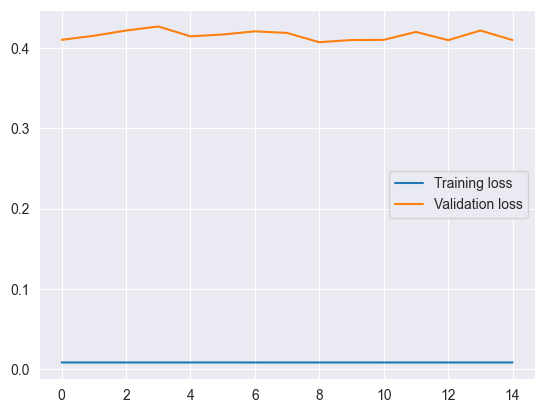

In [41]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()

In [42]:
model.evaluate(testX, testY)

165/165 [==============================] - 4s 24ms/step - loss: 0.1166


0.11658243089914322

249/249 [==============================] - 6s 25ms/step
[0.06236813]


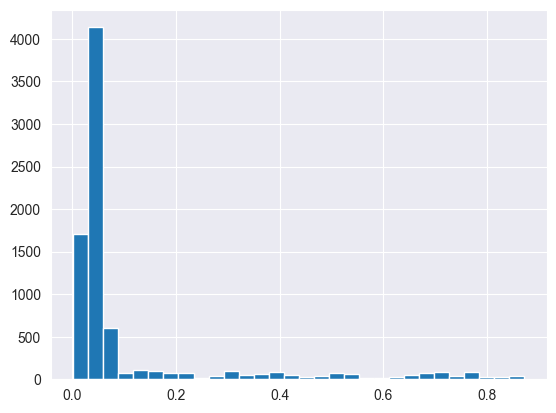

In [43]:
pred_train = model.predict(trainX)
trainMAE = np.mean(np.abs(pred_train - trainX), axis=1)
# var_train = np.var(pred_train - trainX, ddof=1)

plt.hist(trainMAE, bins=30)
print(trainMAE[0])

165/165 [==============================] - 5s 30ms/step


(array([143.,  72., 199., 213., 161., 284., 234., 143., 260., 122., 127.,
        185., 106.,  84., 118., 169., 333., 251., 119., 238., 308., 228.,
         95., 205., 241., 286., 105.,  96., 111.,  42.]),
 array([0.03353503, 0.05210873, 0.07068243, 0.08925614, 0.10782984,
        0.12640354, 0.14497724, 0.16355094, 0.18212464, 0.20069834,
        0.21927204, 0.23784574, 0.25641944, 0.27499315, 0.29356685,
        0.31214055, 0.33071425, 0.34928795, 0.36786165, 0.38643535,
        0.40500905, 0.42358275, 0.44215646, 0.46073016, 0.47930386,
        0.49787756, 0.51645126, 0.53502496, 0.55359866, 0.57217236,
        0.59074606]),
 <BarContainer object of 30 artists>)

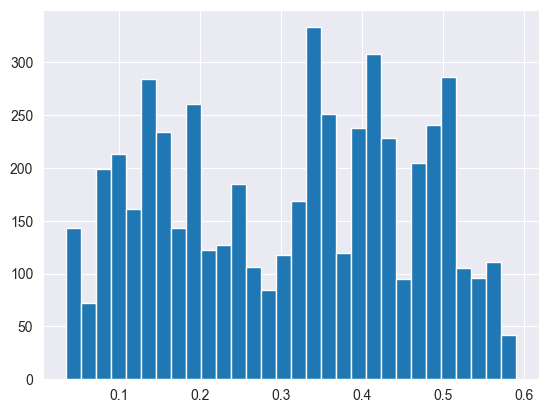

In [45]:
pred_test = model.predict(testX)
testMAE = np.mean(np.abs(pred_test - testX), axis=1)
# var_train = np.var(pred_train - trainX, ddof=1)

plt.hist(testMAE, bins=30)

In [46]:
model.evaluate(testX, testY)

165/165 [==============================] - 4s 24ms/step - loss: 0.1166


0.11658243089914322

In [57]:
anomaly_df = pd.DataFrame(test[seq_size:])
anomaly_df['testMAE'] = testMAE

l = []
for i in range(0,len(trainMAE)) : l.append(trainMAE[i][0])
stat = scipy.stats.describe(l)
print(stat.variance, stat.mean+ (stat.variance)**(0.5)*3)

0.03339139345629798 0.6643664095387742


In [98]:

anomaly_df['max_trainMAE'] = trainMAE.max()
anomaly_df['anomaly'] = anomaly_df['testMAE'] > 0.55
anomaly_df['Close'] = test[seq_size:]['Close']

In [99]:
anomaly_df

,Date,High,Low,Close,Adj Close,Volume,testMAE,max_trainMAE,anomaly
8028,2001-11-05,300.769226,295.692322,0.642426,167.705383,1970904,0.538427,0.87219,False
8029,2001-11-06,307.538452,295.769226,0.659775,172.160782,2184052,0.536863,0.87219,False
8030,2001-11-07,307.384613,300.692322,0.652195,170.214279,1986894,0.535911,0.87219,False
8031,2001-11-08,311.307678,303.461548,0.669038,174.539795,2606175,0.535308,0.87219,False
8032,2001-11-09,311.384613,306.461548,0.670049,174.799469,1533935,0.535051,0.87219,False
...,...,...,...,...,...,...,...,...,...
13301,2022-10-17,70.190002,68.430000,0.139700,68.629997,5141100,0.075586,0.87219,False
13302,2022-10-18,71.139999,69.930000,0.144232,70.699997,6109700,0.074976,0.87219,False
13303,2022-10-19,70.980003,69.339996,0.143860,70.529999,5238500,0.074436,0.87219,False
13304,2022-10-20,71.610001,69.830002,0.142634,69.970001,5987100,0.073872,0.87219,False


In [100]:
anomalies = anomaly_df.loc[anomaly_df['anomaly'] == True]

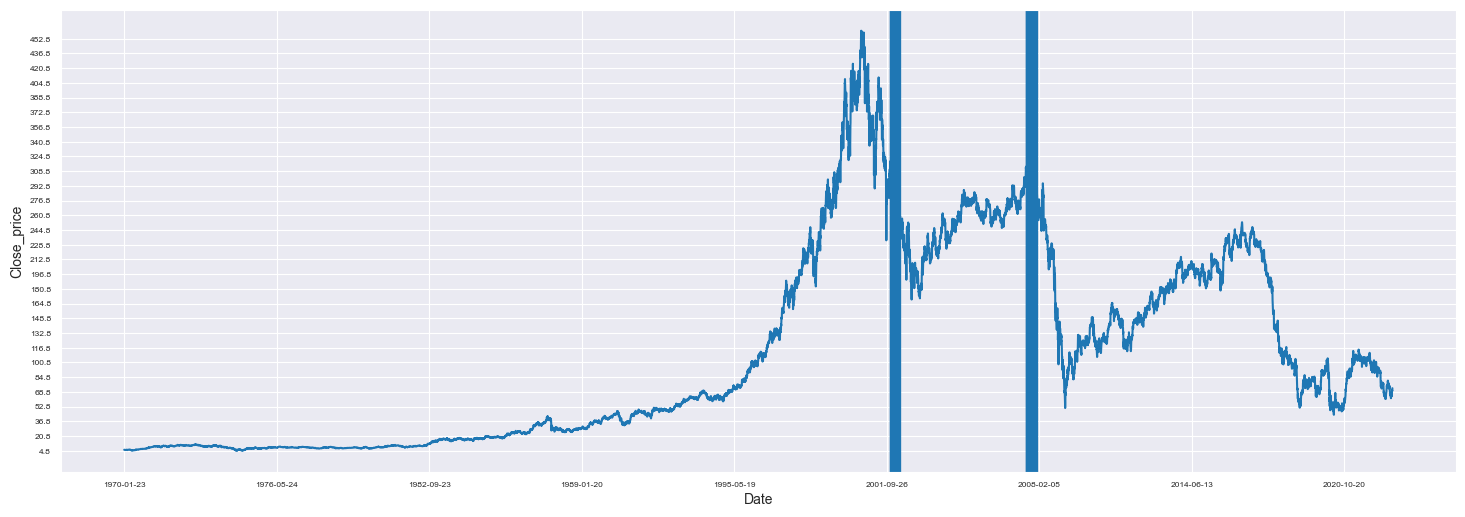

In [101]:
plt.figure(figsize= (18,6))
plt.plot(data['Date'], data['Close'])
plt.xlabel('Date')
plt.ylabel('Close_price')
plt.yticks(np.arange(data['Close'].min(), data['Close'].max(), 16),size = 6)
plt.xticks([ i for i in range(0,data.count()[0],1600) ], size = 6)

for i in (list(anomaly_df['Date'][anomaly_df['anomaly'] == True].values)):
    plt.axvline(x = i)